# Kelly Criterion

## Cumulative Returns

Let $p_t$ be price at time $t$

Percentage Change at time $t$ can be defined like $$r_t = \frac{p_{t+1} - p_t}{p_t} = \frac{p_{t+1}}{p_t} - 1$$

Cumulative return at time $T$ can be defined like $$R_T = \prod_{t=1}^T (r_t + 1) = \frac{p_2}{p_1} \frac{p_3}{p_2}\cdots \frac{p_T}{p_{T-1}} = \frac{p_T}{p_1}$$

## Portfolio Outcomes

Let's define percentage profit size $P$, percentage loss size $L$, and investing fraction $k\in [0, 1]$

In the simple way, we set the profits and losses to be constants.

So, 

portfolio takes profits by percentage profit which can be defined with $$1 + kP$$

and 

portfolio takes losses by percentage loss which can be defined with $$1 - kL$$

Note that profit or loss size can be looked like **"1 + percentage change scaled by $k$ size"**.

Finally, outcome of portfolio is $$P_n = (1 + kP)^{wn}\times (1 - kL)^{(1-w)n}$$

where $n$ is number of trading and $w$ is a proportion of profit taking.

## Optimization

Consider
$$
\begin{align}
\log(P_n) &= \log((1 + kP)^{wn}\times (1 - kL)^{(1-w)n})\\\\
&= \log((1 + kP)^{wn}) + \log((1 - kL)^{(1-w)n})\\\\
&= n\log((1 + kP)^{w}) + n\log((1 - kL)^{(1-w)})\\\\
\frac{\log(P_n)}{n} &= \log((1 + kP)^{w}) + \log((1 - kL)^{(1-w)})\\\\
&= w\log(1 + kP) + (1 - w)\log(1 - kL)\\\\
\end{align}
$$

Now, we need to maximize function $\frac{\log(P_n)}{n}$ to find optimal fraction $k$.

Consider  $\frac{d}{dk}\frac{\log(P_n)}{n} = 0$

$$
\begin{align}
\frac{d}{dk}\frac{\log(P_n)}{n} &= \frac{d}{dk}[w\log(1 + kP) + (1 - w)\log(1 - kL)]\\\\
&= w\frac{d}{dk}[\log(1 + kP)] + (1 - w)\frac{d}{dk}[\log(1 - kL)]\\\\
% &= w\frac{d}{dk}[\log(1 + kP)] + (1 - w)\frac{d}{dk}[\log(1 - kL)]\\\\
&= w\frac{d \log(1 + kP)}{d(1 + kP)}\frac{d (1+kP)}{dk} + (1 - w)\frac{d \log(1 - kL)}{d(1-kL)}\frac{d(1-kL)}{dk}\\\\
&= w\frac{1}{1+kP}P + (1 - w)\frac{1}{1-kL}(-L)\\\\
&= w\frac{1}{1+kP}P - (1 - w)\frac{1}{1-kL}L
\end{align}
$$

So, 

$$w\frac{1}{1+kP}P - (1 - w)\frac{1}{1-kL}L = 0$$

Finally,

$$k = \frac{w}{L} - \frac{(1-w)}{P}$$

Worst downside-scenario is $L=1$, then $P = P/L$ so 

$$k = w - \frac{(1-w)}{P} = w - \frac{(1-w)}{P/L}$$

In [12]:
P = 1
w = 0.66 
k = (P*w - (1 - w)) / P
k

0.32000000000000006

https://en.wikipedia.org/wiki/Kelly_criterion

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Optimal Kelly fraction k*: 0.475


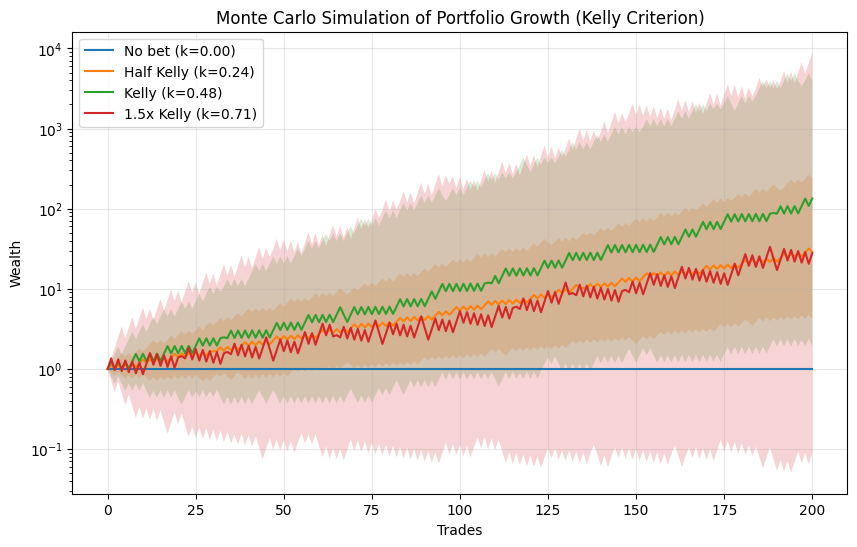

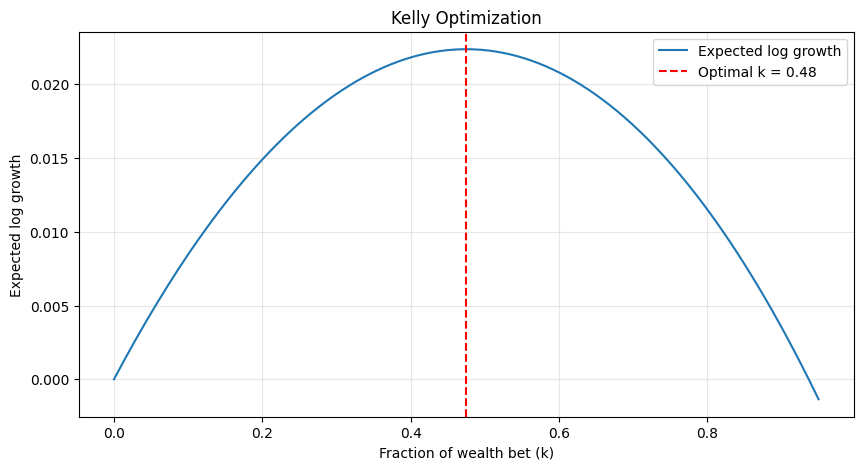

In [3]:
# Parameters
P = 0.5   # profit size (50%)
L = 0.4   # loss size  (40%)
w = 0.55  # win probability
n = 200   # number of trades
trials = 500  # Monte Carlo trials

# --- 1. Analytical Kelly fraction ---
k_opt = w / L - (1 - w) / P
print(f"Optimal Kelly fraction k*: {k_opt:.3f}")

# --- 2. Function to simulate portfolio outcome ---
def simulate_portfolio(k, n, w, P, L, trials=1):
    outcomes = np.zeros((trials, n+1))
    for t in range(trials):
        wealth = 1.0
        outcomes[t,0] = wealth
        for i in range(1, n+1):
            if np.random.rand() < w:
                wealth *= (1 + k*P)
            else:
                wealth *= (1 - k*L)
            outcomes[t,i] = wealth
    return outcomes

# --- 3. Compare growth for different k values with Monte Carlo ---
ks = [0.0, 0.5*k_opt, k_opt, 1.5*k_opt]
labels = ["No bet", "Half Kelly", "Kelly", "1.5x Kelly"]

plt.figure(figsize=(10,6))
for k, label in zip(ks, labels):
    outcomes = simulate_portfolio(k, n, w, P, L, trials=trials)
    median_wealth = np.median(outcomes, axis=0)
    plt.plot(median_wealth, label=f"{label} (k={k:.2f})")
    # also add a band (10th-90th percentile)
    p10 = np.percentile(outcomes, 10, axis=0)
    p90 = np.percentile(outcomes, 90, axis=0)
    plt.fill_between(range(n+1), p10, p90, alpha=0.2)

plt.title("Monte Carlo Simulation of Portfolio Growth (Kelly Criterion)")
plt.xlabel("Trades")
plt.ylabel("Wealth")
plt.yscale("log")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- 4. Expected log growth function ---
def expected_log_growth(k, w, P, L):
    return w*np.log(1 + k*P) + (1-w)*np.log(1 - k*L)

ks_grid = np.linspace(0, min(2*k_opt,1), 200)
growths = [expected_log_growth(k, w, P, L) for k in ks_grid]

plt.figure(figsize=(10,5))
plt.plot(ks_grid, growths, label="Expected log growth")
plt.axvline(k_opt, color='r', linestyle='--', label=f"Optimal k = {k_opt:.2f}")
plt.xlabel("Fraction of wealth bet (k)")
plt.ylabel("Expected log growth")
plt.title("Kelly Optimization")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
